In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/features.csv')
print(df.shape)
df[['dist_road_m', 'dist_hospital_m', 'flood_risk']].describe()

(1125, 6)


,dist_road_m,dist_hospital_m,flood_risk
count,1125.000000,1125.000000,1125.0
mean,31.828569,841.352858,0.0
std,51.479159,606.364145,0.0
min,0.001855,26.118620,0.0
25%,6.856232,398.259416,0.0
50%,15.706206,694.879813,0.0
75%,31.943095,1128.704777,0.0
max,405.938019,3451.963021,0.0


In [2]:
# Labelling rule (justification for the record):
#   A good candidate site has immediate road access (<= 50 m: at most a
#   one-minute walk to a mapped street) AND a hospital within 800 m
#   (~10 minutes on foot -- emergency-access threshold).
#   flood_risk is excluded from the rule: it is a documented placeholder
#   (all zeros, Ex. 4 Note 7) and cannot discriminate between sites.

df['label'] = ((df['dist_road_m'] <= 50) &
               (df['dist_hospital_m'] <= 800)).astype(int)

print(df['label'].value_counts())
print(f"\n{df['label'].mean()*100:.1f}% positive")

label
1    580
0    545
Name: count, dtype: int64

51.6% positive


Matplotlib is building the font cache; this may take a moment.


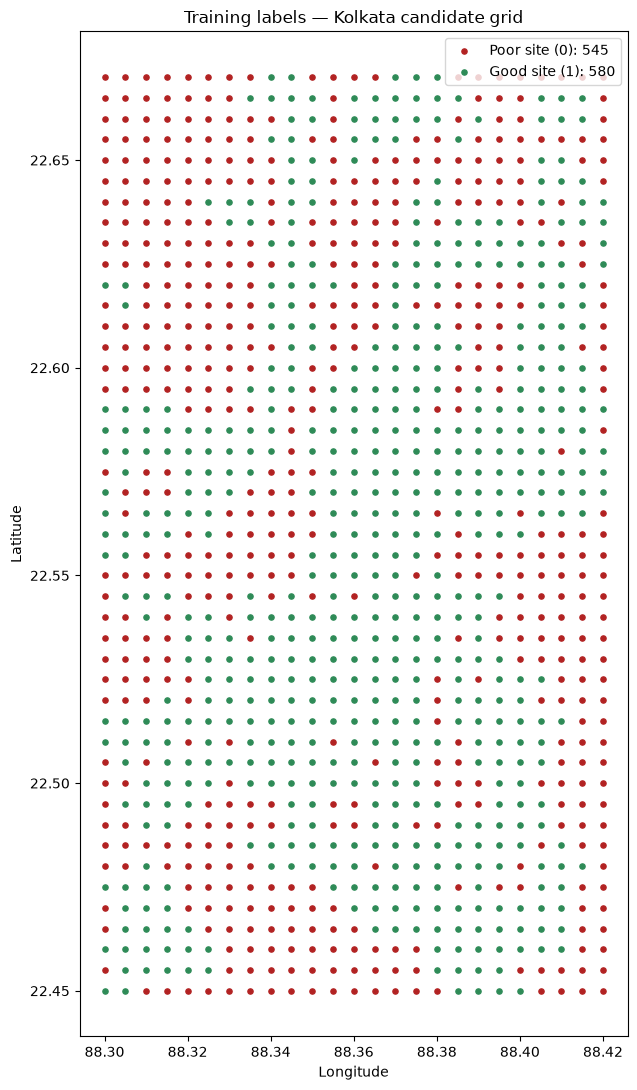

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 11))
good = df[df['label'] == 1]
bad  = df[df['label'] == 0]
ax.scatter(bad.longitude,  bad.latitude,  s=14, c='firebrick', label=f'Poor site (0): {len(bad)}')
ax.scatter(good.longitude, good.latitude, s=14, c='seagreen',  label=f'Good site (1): {len(good)}')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Training labels — Kolkata candidate grid')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../outputs/reports/labels_map.png', dpi=150)
plt.show()

In [4]:
df.to_csv('../data/processed/labelled_sites.csv', index=False)
print('Saved', len(df), 'labelled examples to data/processed/labelled_sites.csv')

Saved 1125 labelled examples to data/processed/labelled_sites.csv
